Model Training

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings


In [2]:
df=pd.read_csv('data/calorie_dataset.csv')

In [3]:
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [4]:
x=df.drop(['Calories'],axis=1)

In [5]:
x.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [6]:
y=df['Calories']

Preparing X and Y

In [7]:
num_feature=x.select_dtypes(include='number').columns
cat_feature=x.select_dtypes(exclude='number').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer=StandardScaler()
cat_transformer=OneHotEncoder(handle_unknown='ignore')

preprocessor=ColumnTransformer(
      transformers=[
            ('num',num_transformer,num_feature),
            ('cat',cat_transformer,cat_feature)
      ]
)

In [8]:
x=preprocessor.fit_transform(x)

In [9]:
x=pd.DataFrame(x)


In [10]:
x.head()

,0,1,2,3,4,5,6,7,8
0,-0.084934,1.484726,1.089582,1.265909,1.619127,0.989404,0.994023,0.0,1.0
1,-0.040261,-1.342179,-0.593726,-0.995458,-0.183990,-0.158461,0.352342,1.0,0.0
2,-1.321900,1.543620,0.318066,0.268247,-1.265861,-0.784569,-1.701035,0.0,1.0
3,0.418779,-0.517665,0.318066,-0.263839,-0.304198,0.467647,0.609015,1.0,0.0
4,0.972783,-0.929922,-1.435380,-1.128480,-0.664821,-1.515029,-0.289338,1.0,0.0


In [11]:
x.isnull().sum()

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((12000, 9), (3000, 9), (12000,), (3000,))

#### Create an Evaluate Function to give all metrics after model Training

In [13]:
def evaluate_model(true,predictions):
      mae=mean_absolute_error(true,predictions)
      mse=mean_squared_error(true,predictions)
      rmse=np.sqrt(mean_squared_error(true,predictions))
      r2_square = r2_score(true, predictions)
      return mae,mse,rmse,r2_square

In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}

model_list = []
r2_list = []

for i in range(len(models)):

    model = list(models.values())[i]

    # Train model
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Evaluate training data
    model_train_mae, model_train_mse, model_train_rmse, model_train_r2 = evaluate_model(
        y_train, y_train_pred
    )

    # Evaluate test data
    model_test_mae, model_test_mse, model_test_rmse, model_test_r2 = evaluate_model(
        y_test, y_test_pred
    )

    print(list(models.keys())[i])

    model_list.append(list(models.keys())[i])

    print('Model performance for Training set')
    print("--------------------------------")
    print("Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("R2 Score: {:.4f}".format(model_train_r2))

    print("--------------------------------")

    print('Model performance for Test set')
    print("--------------------------------")
    print("Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("R2 Score: {:.4f}".format(model_test_r2))

    r2_list.append(model_test_r2)

    print('=' * 35)
    print()

Linear Regression
Model performance for Training set
--------------------------------
Root Mean Squared Error: 11.2659
Mean Absolute Error: 8.3042
R2 Score: 0.9672
--------------------------------
Model performance for Test set
--------------------------------
Root Mean Squared Error: 11.4921
Mean Absolute Error: 8.4437
R2 Score: 0.9673

Lasso
Model performance for Training set
--------------------------------
Root Mean Squared Error: 12.2544
Mean Absolute Error: 9.0122
R2 Score: 0.9612
--------------------------------
Model performance for Test set
--------------------------------
Root Mean Squared Error: 12.5656
Mean Absolute Error: 9.1473
R2 Score: 0.9609



Ridge
Model performance for Training set
--------------------------------
Root Mean Squared Error: 11.2659
Mean Absolute Error: 8.3039
R2 Score: 0.9672
--------------------------------
Model performance for Test set
--------------------------------
Root Mean Squared Error: 11.4923
Mean Absolute Error: 8.4434
R2 Score: 0.9673

K-Neighbors Regressor
Model performance for Training set
--------------------------------
Root Mean Squared Error: 5.5819
Mean Absolute Error: 4.0704
R2 Score: 0.9919
--------------------------------
Model performance for Test set
--------------------------------
Root Mean Squared Error: 6.5825
Mean Absolute Error: 4.8747
R2 Score: 0.9893

Decision Tree
Model performance for Training set
--------------------------------
Root Mean Squared Error: 0.0000
Mean Absolute Error: 0.0000
R2 Score: 1.0000
--------------------------------
Model performance for Test set
--------------------------------
Root Mean Squared Error: 5.5746
Mean Absolute Error: 3.5930
R2 Score: 0.99

In [15]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
7,CatBoosting Regressor,0.999894
6,XGBRegressor,0.998791
5,Random Forest Regressor,0.998010
4,Decision Tree,0.992300
3,K-Neighbors Regressor,0.989264
8,AdaBoost Regressor,0.967603
0,Linear Regression,0.967276
2,Ridge,0.967274
1,Lasso,0.960876


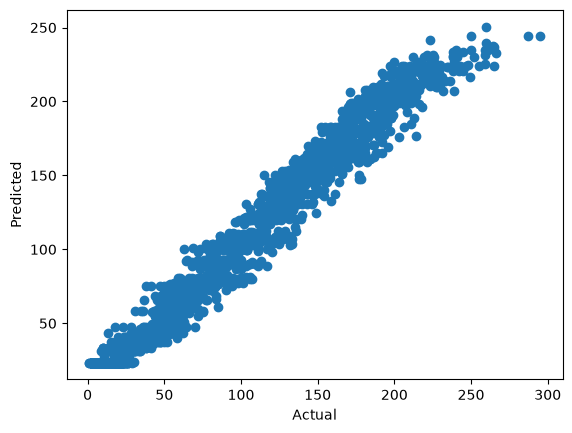

In [16]:
plt.scatter(y_test,y_test_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

<Axes: xlabel='Calories'>

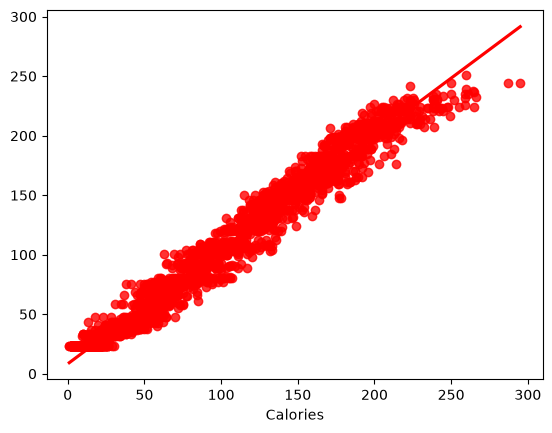

In [19]:
sns.regplot(x=y_test,y=y_test_pred, color='red',ci=None)